**Breast Cancer Diagnosis: Benign vs Malignant using Logistic Regression (Binary Classification)**

For my AML-BASIC project, I selected the Breast Cancer Wisconsin (Diagnostic) dataset from the Suggested Datasets document.

This dataset contains 569 samples, each with 30 nuclear features (e.g., radius, texture), derived from Fine Needle Aspiration (FNA) biopsies.

**Project Objectives**

In this project, I aim to address the following challenges:

Feature Engineering: Create meaningful indicators from the raw features, including mean values, standard errors, and extreme values.

Handling Class Imbalance: The dataset has 357 benign samples and 212 malignant samples, requiring careful treatment to avoid biased predictions.

**Additional Improvements**

Based on the feedback from my first submission, this version includes a complete workflow:

Hypothesis formulation

Data exploration and visualization

Baseline model comparison

Logistic regression model building

Result interpretation

The report format has been optimized by combining Markdown cells with executable code blocks, enhancing readability and clarity.

1. Hypothsesis

Hypothesis: The morphological features of breast cell nuclei are highly correlated with the benign or malignant nature of the tumor.
Objective: Use a machine learning method (logistic regression) to classify the extracted 30 features and determine whether the tumor is benign or malignant.
Method: Binary classification with an additional Dummy Baseline for comparison.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve, roc_auc_score)

**2. Data Loading and Preliminary Exploration**



   

In [33]:
data_path = r"D:\Downloads\breast+cancer+wisconsin+diagnostic\wdbc.data"


In [14]:
# Column names
column_names = [
    'ID', 'diagnosis',
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
    'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
    'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst',
    'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]


In [17]:
df = pd.read_csv('wdbc.data', header=None, names=column_names)


In [18]:
df.head()  

,ID,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Explanation

Because the original file does not contain column names, they are specified here (the first 10 are means, the middle 10 are standard errors (SE), and the last 10 are worst values).
The names come from the wdbc.names file (which has been uploaded to GitHub).





**3. Data Exploration (EDA)**
**3.1 Label Conversion**

In [19]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})   # Convert the diagnosis column from B/M strings to 0/1 numbers for machine learning.

**3.2 Missing Values and Data Type check**





In [34]:
# Basic information Check for missing values and verify if data types are correct
df.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       569 non-null    int64  
 1   diagnosis                569 non-null    int64  
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

Explanation

All columns have 569 entries, indicating no missing values.
Data types are normal: diagnosis is already int64, which means the map({'M': 1, 'B': 0}) conversion has worked; except for the ID column, all others are float64.
Memory usage is normal.
Before modeling, drop(['ID', 'diagnosis']) will be used to remove the ID and label columns to ensure clean input features.

**3.3 Numerical Distribution Overview (Descriptive Statistics)**

In [21]:
# Descriptive statistics Mainly check the distribution of numerical features
df.describe()

,ID,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


**Explanation**

The descriptive statistics show that the value ranges of each feature vary greatly — for example, radius_mean has a maximum of about 28, while smoothness_mean has a maximum of only 0.1634.
The scale differences between features are obvious, so standardization is needed later to eliminate unit effects.
It also verifies that there are no abnormal extreme values (for example, area_mean has a maximum of 2501, which is within the expected range for real breast lumps).

**3.4 Example of Univariate Distribution (Histogram)**

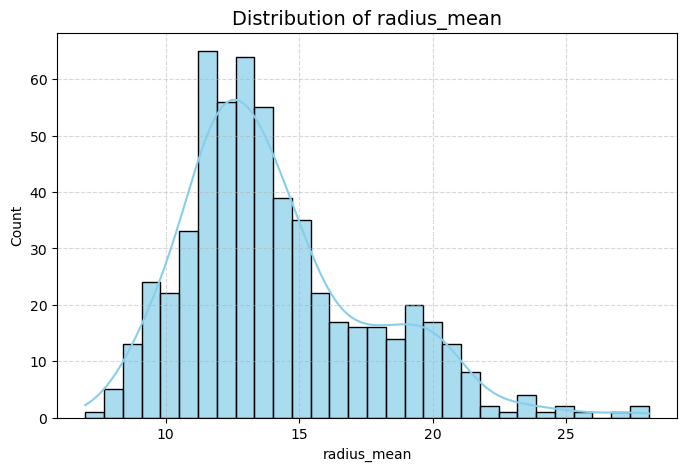

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['radius_mean'], bins=30, kde=True, color='skyblue', alpha=0.7)
plt.title("Distribution of radius_mean", fontsize=14)
plt.xlabel("radius_mean")
plt.ylabel("Count")
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("radius_mean_hist.png", dpi=300)
plt.show()

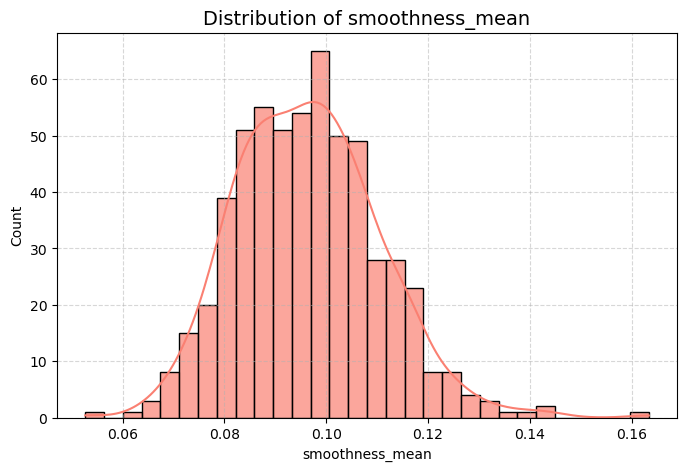

In [24]:
# 2. smoothness_mean histogram
plt.figure(figsize=(8,5))
sns.histplot(df['smoothness_mean'], bins=30, kde=True, color='salmon', alpha=0.7)
plt.title("Distribution of smoothness_mean", fontsize=14)
plt.xlabel("smoothness_mean")
plt.ylabel("Count")
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("smoothness_mean_hist.png", dpi=300)
plt.show()

**explanation of Univariate Distributions**

The top figure shows the distribution of radius_mean (mean nuclear radius). Most samples are concentrated around 10 to 17, slightly right-skewed, with some samples reaching above 25, indicating a few outliers with relatively large radii.
The bottom figure shows the distribution of smoothness_mean (mean nuclear smoothness). The range is much smaller (0.06 ~ 0.16) and the distribution is nearly normal and concentrated, with very few extreme values.
From these two figures, it can be seen that the value ranges of different features vary greatly, further confirming the necessity of standardization processing later. (Only radius_mean and smoothness_mean were selected as representative features to show univariate distributions.)

**3.5 Diagnosis Label Distribution (Class Imbalance)**

In [25]:
# Prepare data
label_counts = df['diagnosis'].value_counts()
labels = ['Benign (B)', 'Malignant (M)']
colors = ['#4CAF50', '#F44336']  # green for benign, red for malignant

/tmp/ipykernel_161/3415747350.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=label_counts.values, palette=colors)


(0.0, 392.70000000000005)

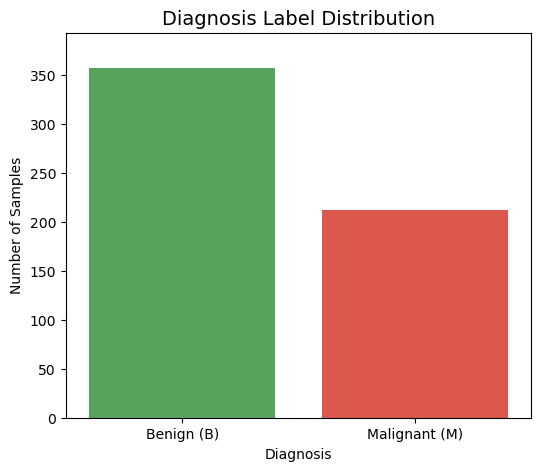

In [26]:
# Create barplot
plt.figure(figsize=(6,5))
sns.barplot(x=labels, y=label_counts.values, palette=colors)
plt.title("Diagnosis Label Distribution", fontsize=14)
plt.ylabel("Number of Samples")
plt.xlabel("Diagnosis")
plt.ylim(0, max(label_counts.values)*1.1)

**Explanation**

It can be seen that the proportion of benign and malignant cases is imbalanced, with more benign cases.
This indicates the need to consider class weights in the model (class_weight='balanced') to avoid bias toward the majority class.

**3.6 Feature Correlation Heatmap**




/tmp/ipykernel_161/2794916246.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=label_counts.values, palette=colors)


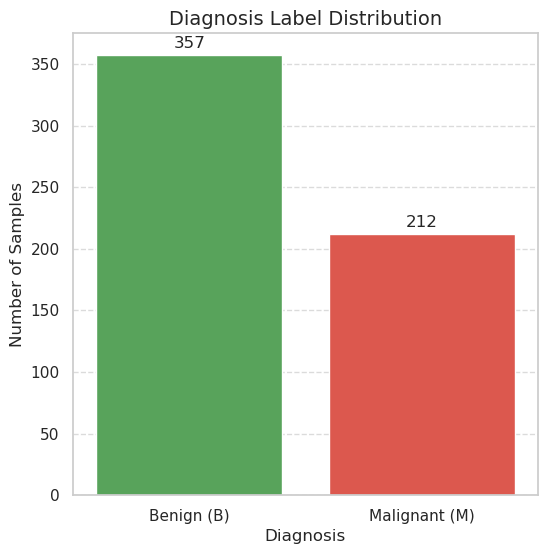

diagnosis
0    357
1    212
Name: count, dtype: int64


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style
sns.set(style="whitegrid")

# Prepare data
label_counts = df['diagnosis'].value_counts()
labels = ['Benign (B)', 'Malignant (M)']
colors = ['#4CAF50', '#F44336']

# Create a figure with fixed size
plt.figure(figsize=(6,6))  # fixed, reasonable size

# Plot barplot
sns.barplot(x=labels, y=label_counts.values, palette=colors)

# Title and labels
plt.title("Diagnosis Label Distribution", fontsize=14)
plt.ylabel("Number of Samples")
plt.xlabel("Diagnosis")

# Add count numbers above bars safely
for i, count in enumerate(label_counts.values):
    plt.text(i, count + max(label_counts.values)*0.01, str(count),
             ha='center', va='bottom', fontsize=12)

# Gridlines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save figure
plt.savefig("label_distribution_safe.png", dpi=300, bbox_inches='tight')
plt.show()

# Print counts
print(label_counts)


**Explanation**

It can be seen that the proportion of benign and malignant cases is imbalanced, with more benign cases.
This indicates the need to consider class weights in the model (class_weight='balanced') to avoid bias toward the majority class.

**3.6 Feature Correlation Heatmap**

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

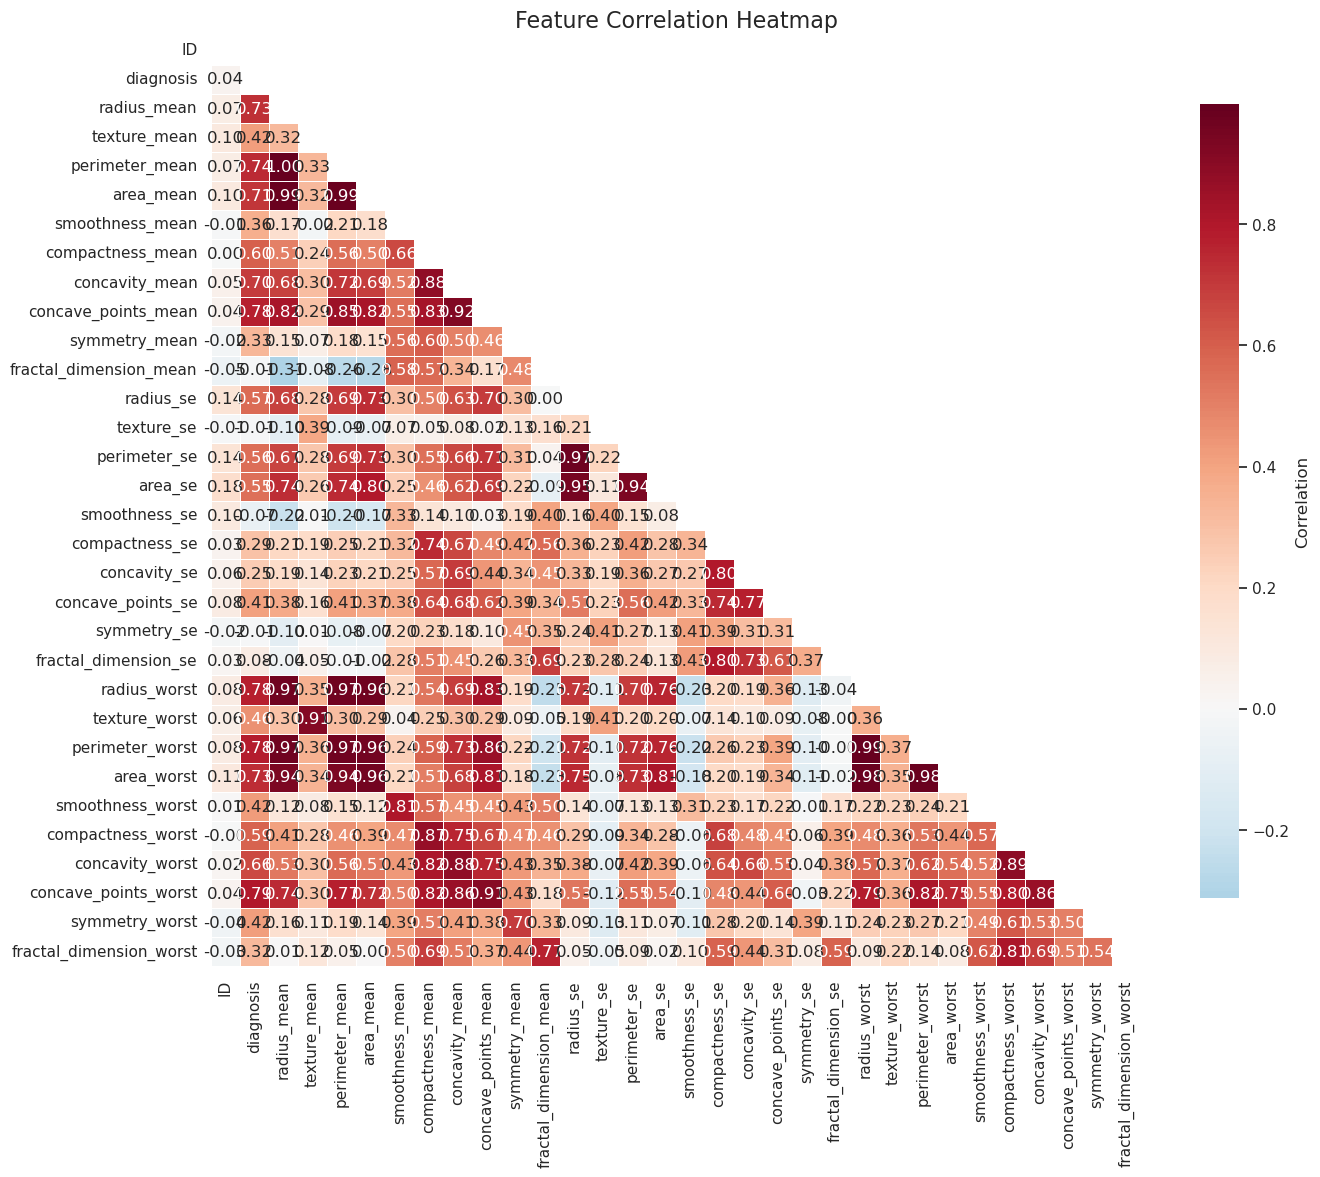

In [37]:


# Set Seaborn style
sns.set(style="white")

# Compute correlation matrix
corr = df.corr()  # <- This must be defined

# Create a mask for the upper triangle (optional)
mask = np.triu(np.ones_like(corr, dtype=bool))

# Create figure
plt.figure(figsize=(14,12))

# Draw heatmap
sns.heatmap(
    corr,
    mask=mask,               # only show lower triangle
    cmap='RdBu_r',           # diverging colormap
    center=0,                # center at 0
    annot=True,              # show correlation values
    fmt=".2f",               # format numbers
    square=True,             # square cells
    linewidths=0.5,          # lines between cells
    cbar_kws={"shrink": 0.8, "label": "Correlation"}
)

plt.title("Feature Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.savefig("correlation_heatmap_mod.png", dpi=300)
plt.show()


Explanation

The correlation heatmap shows that some features are strongly correlated (for example, radius_mean and perimeter_mean, area_mean are clearly highly correlated), which may indicate redundancy.
It is also visible that some worst-value features and mean-value features are highly correlated (e.g., radius_worst and radius_mean).
In later steps, regularization and feature selection (e.g., removing highly correlated columns) will be applied to reduce the risk of multicollinearity.
Correlation with diagnosis will also be considered to further analyze which features are most closely related to classification.

**3.7 Correlation Between Diagnosis Label and Each Feature**

In [32]:
df_no_id = df.drop(columns=['ID'])

corr_with_target = df_no_id.corr()['diagnosis'].sort_values(ascending=False)

print("Top correlated features with diagnosis:\n")
print(corr_with_target.head(6).to_string())

print("\nLeast correlated features with diagnosis:\n")
print(corr_with_target.tail(6).to_string())

Top correlated features with diagnosis:

diagnosis               1.000000
concave_points_worst    0.793566
perimeter_worst         0.782914
concave_points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636

Least correlated features with diagnosis:

concavity_se              0.253730
fractal_dimension_se      0.077972
symmetry_se              -0.006522
texture_se               -0.008303
fractal_dimension_mean   -0.012838
smoothness_se            -0.067016


Explanation

By calculating the Pearson correlation between diagnosis and all numerical features, you can clearly see which features are most strongly associated with benign or malignant tumors.
For example, shape- and contour-related features like concave_points_worst, perimeter_worst, and radius_worst show significant positive correlation with the diagnosis result (correlation coefficient about 0.74 ~ 0.79).
Some subtle features such as fractal_dimension and smoothness_se have relatively low or slightly negative correlation with the label. These will be automatically penalized by L2 regularization during modeling to shrink unimportant feature weights and avoid overfitting.

**4. Data Preparation**
4.1 Remove Highly Correlated Features



s